# Hartmann6


The Hartmann function family is commonly used to benchmark optimization algorithms. Here, the six-dimensional case is considered, which has six local minima. The global minimum is located at $\boldsymbol{x}^{*}=\begin{bmatrix}0.20169 &0150011 &0.476874 &0.275332 &0.311652&0.6573\end{bmatrix}^\top$ where the function value is $-3.32237$. The computational domain is defined as $\Omega=[0,1]^6$. The multi-fidelity formulation studied in \cite{kandasamy2019} defines the $s$-th fidelity level as
\begin{equation*}
    f^{(s)}(\boldsymbol{x}) = \sum_{i=1}^4 \alpha_i^{(s)} 
    \exp\left(-\sum_{j=1}^6 A_{ij}(x_j - P_{ij})^2\right),
\end{equation*}
where $A, P \in \mathbb{R}^{4 \times 6}$ are fixed matrices defined as
\begin{equation*}
    A :=
    \begin{bmatrix}
    10 & 3 & 17 & 3.5 & 1.7 & 8 \\
    0.05 & 10 & 17 & 0.1 & 8 & 14 \\
    3 & 3.5 & 1.7 & 10 & 17 & 8 \\
    17 & 8 & 0.05 & 10 & 0.1 & 14
    \end{bmatrix}, 
    \qquad
    P := 10^{-4}
    \begin{bmatrix}
    1312 & 1696 & 5569 & 124 & 8283 & 5886 \\
    2329 & 4135 & 8307 & 3736 & 1004 & 9991 \\
    2348 & 1451 & 3522 & 2883 & 3074 & 6650 \\
    4047 & 8828 & 8732 & 5743 & 1091 & 381
    \end{bmatrix}.
\end{equation*}
The fidelity-dependent parameter vector $\boldsymbol{\alpha}^{(s)}$ is defined as
\begin{equation*}
    \boldsymbol{\alpha}^{(s)} := \boldsymbol{\alpha} + (S - s)\boldsymbol{\delta},
    \qquad \text{with} \qquad
    \begin{cases}
    \boldsymbol{\alpha} := 
    \begin{bmatrix}
    1 & 1.2 & 3 & 3.2
    \end{bmatrix}^\top, \\[0.3em]
    \boldsymbol{\delta} :=
    \begin{bmatrix}
    0.01 & -0.01 & -0.1 & 0.1
    \end{bmatrix}^\top.
    \end{cases}
\end{equation*}
Following \cite{letham2019}, a single constraint is imposed to restrict feasible points to lie inside the unit sphere: $\|\boldsymbol{x}\| \leq 1$.


## Imports

In [1]:
import sys, os
sys.path.insert(0, os.getcwd()) #equivalent to " export PYTHONPATH="$PWD:$PYTHONPATH" "

In [2]:
from mfscbo.functions import Hartmann6
from mfscbo.mfscbo_optimization import ScboMfOptimizer
from mfscbo.plot import plot_rhos, plot_noises, plot_bestYs, plot_nbiters, plot_tr_lengths
from mfscbo.utils import eval_fun_unnormalized
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

## Problem setup

In [3]:
# Define torch arguments
torchargs = {
    "device": "cpu",
    "dtype": torch.double
}

In [4]:
# Define evaluation objectives at different fidelities
f0_ = Hartmann6(fidelity=1, fidelity_high=3, torchargs=torchargs)
f1_ = Hartmann6(fidelity=2, fidelity_high=3, torchargs=torchargs)
f2_ = Hartmann6(fidelity=3, fidelity_high=3, torchargs=torchargs)

# Define bounds and dimension
bounds = f0_.bounds
dim = bounds.shape[1]

# Convert to maximization problem (SCBO expects maximization) and unnormalize
f0 = lambda x: -eval_fun_unnormalized(x, f0_, bounds)
f1 = lambda x: -eval_fun_unnormalized(x, f1_, bounds)
f2 = lambda x: -eval_fun_unnormalized(x, f2_, bounds)
eval_objectives = [f0, f1, f2]

In [5]:
# Define constraints (use bilog transformation for the constraints)
def constraints(x) :
    c1 = torch.norm(x, dim=1)**2 - 1
    return c1[:,None]

def log_constraints(x) :
    c = constraints(x)
    return torch.sign(c) * torch.log(1 + torch.abs(c))

def eval_constraints(x) :
    return eval_fun_unnormalized(x, log_constraints, bounds)

In [6]:
# Define number of initial points, rhos, and costs for each fidelity
n_pts = [12, 9, 3]  # total 4*dim = 12+9+3
rhos = [1, 1, 1]
costs = [1, 10, 20]

## Optimization

In [7]:
# Initialize and run the SCBO optimizer
optimizer = ScboMfOptimizer(
    eval_objectives=eval_objectives,
    constraints=constraints,
    rhos=rhos,
    costs=costs,
    dim=dim,
    n_pts=n_pts,
    bounds=bounds,
    type_of_batch="sequential",
    type_of_centering="evaluated",
    torchargs=torchargs,
    restart=True,
    test=True,  # Predictive mode
)
optimizer.initialize()
optimizer.optimize(max_cost=2000, batch_size=8, path="results/Hartmann6", verbose=True)

Starting MF-SCBO optimization...
Max cost : 2000
Batch size : 8
Path : results/Hartmann6

========================= Parameters for MF-SCBO Optimization ==========================
________________________________________________________________________________________
| Parameter         | Value                                                            |
----------------------------------------------------------------------------------------
| dim               | 6                                                                |
| bounds            | [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0]] |
| nb_fidelities     | 3                                                                |
| n_pts             | [12, 9, 3]                                                       |
| rhos              | [1, 1, 1]                                                        |
| costs             | [1, 10, 20]                                                      |
| type_of_batch     

(tensor([0.1670, 0.1222, 0.4003, 0.3285, 0.3078, 0.7282], dtype=torch.float64),
 3.0546451065526923)

## Post process

In [11]:
# Load results
data = np.load("results/Hartmann6/MFSCBO_data.npz", allow_pickle=True)
gps_info = data["gps_info"]
iterations = data["iterations"]
xvalues = data["cost_iter"]
bestY = -data["best_Y"] #for minimization plot
nbiters = data["nb_iter"]
tr_lengths = data["trust_region_lengths"]

In [12]:
# Post-process rhos
rhos = [[1] for _ in range(len(gps_info)-1)]  # no rho for fidelity 0
for fid in range(1, len(gps_info)):
    for it in range(len(iterations)-1):
        rhos[fid-1].append(gps_info[fid][it]["rho"])

# Post-process noises
noises = [[] for _ in range(len(gps_info))]
for fid in range(len(gps_info)):
    for it in range(len(iterations)-1):
        noises[fid].append(gps_info[fid][it]["noise"])

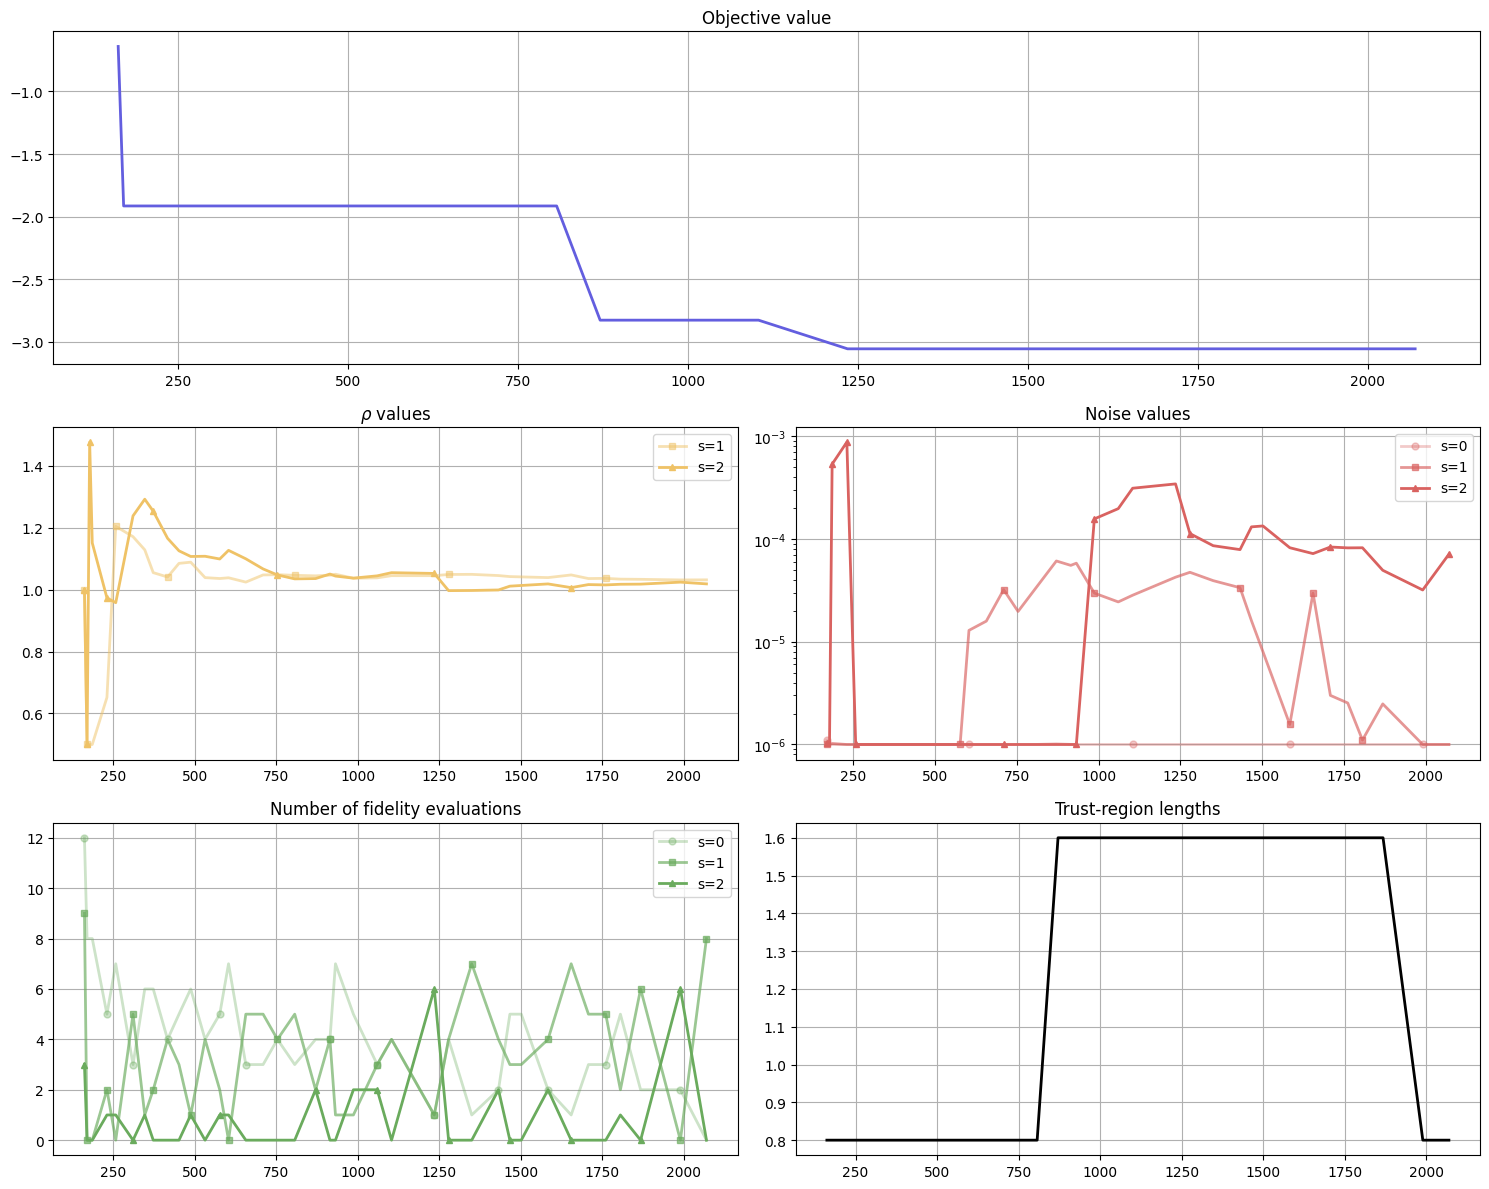

In [13]:
# Plot results
fig = plt.figure(figsize=(15, 12))
gs = GridSpec(3, 2, figure=fig)
ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])
ax4 = fig.add_subplot(gs[2, 0])
ax5 = fig.add_subplot(gs[2, 1])

plot_bestYs(bestY, xvalues, ax=ax1)
plot_rhos(rhos, xvalues, ax=ax2)
plot_noises(noises, xvalues[1:], ax=ax3)
plot_nbiters(nbiters, xvalues, ax=ax4)
plot_tr_lengths(tr_lengths, xvalues, ax=ax5)

# Set titles, legends, and grids
ax1.set_title("Objective value")
ax1.grid()
ax2.set_title(r"$\rho$ values")
ax2.legend()
ax2.grid()
ax3.set_title("Noise values")
ax3.legend()
ax3.grid()
ax3.set_yscale("log")
ax4.set_title("Number of fidelity evaluations")
ax4.legend()
ax4.grid()
ax5.set_title("Trust-region lengths")
ax5.grid()

plt.tight_layout()
plt.savefig("results/Hartmann6/MFSCBO_plots.pdf")
plt.show()